04 — Phase Trajectory + Continuity Conditioning

목표: 아래 per-step condition을 사용해 continuity-aware phase trajectory 모델을 학습합니다.

[cosϕt, sinϕt, cos(ϕt−ϕt−1), sin(ϕt−ϕt−1)]

출력 checkpoint: artifacts/checkpoints/phase_trajectory_continuity_ckpt.pt
출력 figure: artifacts/figures/phase_trajectory_continuity_loss.png, phase_trajectory_continuity_sensitivity.png

In [1]:
# Google Drive mount and project-root setup for Colab
from pathlib import Path
import os

PROJECT_CANDIDATES = [
    Path('/content/drive/MyDrive/phase_conditioned_diffusion_policy (1)'),
    Path('/content/drive/MyDrive/phase_conditioned_diffusion_policy'),
]

try:
    from google.colab import drive
except ImportError:
    print(f'Not running in Google Colab; keeping current working directory: {Path.cwd()}')
else:
    drive.mount('/content/drive')

    PROJECT_DIR = next((p for p in PROJECT_CANDIDATES if p.exists()), None)
    if PROJECT_DIR is None:
        tried = '\n'.join(str(p) for p in PROJECT_CANDIDATES)
        raise FileNotFoundError(f'Expected project directory not found. Tried:\n{tried}')

    os.chdir(PROJECT_DIR)

# Must be set before importing pcdp.paths.
os.environ['PCDP_ARTIFACT_ROOT'] = str(Path.cwd() / 'artifacts')

print(f'Current working directory: {Path.cwd()}')
print(f'PCDP_ARTIFACT_ROOT: {os.environ["PCDP_ARTIFACT_ROOT"]}')


Mounted at /content/drive
Current working directory: /content/drive/MyDrive/phase_conditioned_diffusion_policy (1)
PCDP_ARTIFACT_ROOT: /content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts


In [2]:
# Colab dependency setup
import importlib.util
import subprocess
import sys
from pathlib import Path

if importlib.util.find_spec('google.colab') is None:
    print('Not running in Google Colab; skipping dependency installation and using the current environment.')
else:
    project_root = Path.cwd()
    requirements_path = project_root / 'requirements.txt'
    install_command = [sys.executable, '-m', 'pip', 'install']

    if requirements_path.exists():
        install_command.extend(['-r', str(requirements_path), '-e', str(project_root)])
    else:
        install_command.extend(['-e', str(project_root)])

    subprocess.check_call(install_command)

    import gymnasium as gym
    import mujoco
    import minari
    import torch

    gym.make('Ant-v5').close()

    print(f'gymnasium={gym.__version__}')
    print(f'mujoco={mujoco.__version__}')
    print(f'minari={minari.__version__}')
    print(f'torch={torch.__version__}')
    print('Ant-v5 environment smoke check passed.')


gymnasium=1.3.0
mujoco=3.9.0
minari=0.5.3
torch=2.11.0+cu128
Ant-v5 environment smoke check passed.


## 1. Artifact paths

In [3]:
from pcdp.paths import ARTIFACT_ROOT, DATA_DIR, CHECKPOINTS_DIR, FIGURES_DIR, ensure_artifact_dirs

ensure_artifact_dirs()

print(f'✓ artifact root: {ARTIFACT_ROOT}')
print(f'✓ data dir: {DATA_DIR}')
print(f'✓ checkpoints dir: {CHECKPOINTS_DIR}')
print(f'✓ figures dir: {FIGURES_DIR}')


✓ artifact root: /content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts
✓ data dir: /content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts/data
✓ checkpoints dir: /content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts/checkpoints
✓ figures dir: /content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts/figures


## 2. Imports + Continuity Config

In [4]:
import torch
from dataclasses import replace

from pcdp.configs import get_experiment_config, ArtifactConfig
from pcdp.dataset import encode_phase_cossin
from pcdp.experiment_plots import plot_action_chunks, plot_loss_curve
from pcdp.experiment_runner import (
    build_model,
    build_noise_scheduler,
    load_data_and_build_loaders,
    sample_frequency_variants,
)
from pcdp.training import train_diffusion_policy, save_checkpoint, load_checkpoint
from pcdp.evaluation import build_frequency_sweep_protocol

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__}, device={device}')
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

# Start from the original phase_trajectory config but change only the parts needed for continuity conditioning.
base_cfg = get_experiment_config('phase_trajectory')
cfg = replace(
    base_cfg,
    name='phase_trajectory_continuity',
    display_name='Phase Trajectory + Continuity Conditioning',
    train_cond_fn='notebook_trajectory_phase_continuity_cond_fn',
    sample_cond_fn='notebook_trajectory_phase_continuity_sample_cond_fn',
    model=replace(base_cfg.model, per_step_cond_dim=4),
    artifacts=ArtifactConfig(
        checkpoint_name='phase_trajectory_continuity_ckpt.pt',
        loss_plot_name='phase_trajectory_continuity_loss.png',
    ),
    tags=('phase', 'per-step-cond', 'continuity'),
)

print(f'Experiment config: {cfg.name} — {cfg.display_name}')
print(f'per_step_cond_dim: {cfg.model.per_step_cond_dim}')
print(f'checkpoint: {cfg.artifacts.checkpoint_name}')


PyTorch 2.11.0+cu128, device=cuda
Tesla T4
Experiment config: phase_trajectory_continuity — Phase Trajectory + Continuity Conditioning
per_step_cond_dim: 4
checkpoint: phase_trajectory_continuity_ckpt.pt


## 3. Continuity conditioning functions

In [5]:
def encode_phase_continuity(phase: torch.Tensor, prev_phase: torch.Tensor) -> torch.Tensor:
    '''
    phase: (B, T)
    prev_phase: (B,)
    return: (B, T, 4)

    Features:
    [cos(phi_t), sin(phi_t), cos(phi_t - phi_{t-1}), sin(phi_t - phi_{t-1})]
    '''
    phase_enc = encode_phase_cossin(phase)  # (B, T, 2)
    prev = torch.cat([prev_phase[:, None], phase[:, :-1]], dim=1)  # (B, T)
    delta = phase - prev
    delta_enc = encode_phase_cossin(delta)  # (B, T, 2)
    return torch.cat([phase_enc, delta_enc], dim=-1)  # (B, T, 4)


def trajectory_phase_continuity_cond_fn(batch: dict, device: str):
    '''Training-time continuity-aware phase trajectory conditioning.'''
    obs = batch['obs'].to(device, non_blocking=True)
    phase = batch['phase'].to(device, non_blocking=True)

    # The original dataset does not need to be modified. If prev_phase is absent,
    # approximate it from the first local phase advance, matching sampling-time behavior.
    if 'prev_phase' in batch:
        prev_phase = batch['prev_phase'].to(device, non_blocking=True)
    else:
        if phase.shape[1] >= 2:
            delta0 = phase[:, 1] - phase[:, 0]
        else:
            delta0 = torch.zeros_like(phase[:, 0])
        prev_phase = phase[:, 0] - delta0

    global_cond = obs.flatten(start_dim=1)
    per_step_cond = encode_phase_continuity(phase, prev_phase)
    return global_cond, per_step_cond


def trajectory_phase_continuity_sample_cond_fn(
    obs_window: torch.Tensor,
    phase_chunk: torch.Tensor,
    device: str = 'cuda',
):
    '''Sampling-time continuity-aware phase trajectory conditioning.'''
    obs_window = obs_window.to(device)
    phase_chunk = phase_chunk.to(device)

    if phase_chunk.shape[1] >= 2:
        delta0 = phase_chunk[:, 1] - phase_chunk[:, 0]
    else:
        delta0 = torch.zeros_like(phase_chunk[:, 0])
    prev_phase = phase_chunk[:, 0] - delta0

    global_cond = obs_window.flatten(start_dim=1)
    per_step_cond = encode_phase_continuity(phase_chunk, prev_phase)
    return global_cond, per_step_cond

print('✓ continuity conditioning ready')


✓ continuity conditioning ready


## 4. Data

In [6]:
data, train_ds, val_ds, train_loader, val_loader = load_data_and_build_loaders(cfg, DATA_DIR)

# Sanity check: per-step condition must be (B, PRED_HORIZON, 4).
batch = next(iter(train_loader))
global_cond, per_step_cond = trajectory_phase_continuity_cond_fn(batch, device)
print('batch keys:', batch.keys())
print('global_cond:', tuple(global_cond.shape))
print('per_step_cond:', tuple(per_step_cond.shape))
assert per_step_cond.shape[-1] == 4, 'Continuity condition dimension must be 4.'


Train dataset:
  AntPhaseDataset: 102 episodes → 18768 chunks
Val dataset:
  AntPhaseDataset: 18 episodes → 3312 chunks
  Train batches/epoch: 73
  Val batches/epoch:   13
✓ Experiment seed: 42
batch keys: dict_keys(['obs', 'action', 'phase'])
global_cond: (256, 210)
per_step_cond: (256, 16, 4)


## 5. Model + Scheduler

In [7]:
model = build_model(cfg, data, device=device)
noise_scheduler, ns_config, NUM_INFERENCE_STEPS = build_noise_scheduler(cfg)
ema = cfg.build_ema(model)


Total params:     68.30M
Trainable params: 68.30M
DDPM: 100 train steps, squaredcos_cap_v2, epsilon-prediction


## 6. Train or Load

In [8]:
TRAIN = True
CKPT_PATH = cfg.checkpoint_path(CHECKPOINTS_DIR)

if TRAIN:
    train_losses, val_log, best_ema_state = train_diffusion_policy(
        model=model,
        ema=ema,
        noise_scheduler=noise_scheduler,
        train_loader=train_loader,
        val_loader=val_loader,
        cond_fn=trajectory_phase_continuity_cond_fn,
        device=device,
        **cfg.training_kwargs(),
    )
    save_checkpoint(
        CKPT_PATH,
        model=model,
        ema=ema,
        train_losses=train_losses,
        val_log=val_log,
        best_ema_state=best_ema_state,
        config=cfg.to_dict(),
    )

    if best_ema_state is not None:
        ema_state = ema.state_dict()
        ema_state.update(best_ema_state)
        ema.load_state_dict(ema_state)
        print('✓ Best EMA applied')
    print(f'✓ Training complete: {CKPT_PATH}')
else:
    meta = load_checkpoint(CKPT_PATH, model, ema, device=device, use_best_ema=True)
    train_losses = meta['train_losses']
    val_log = meta['val_log']
    best_ema_state = meta['best_ema_state']
    print(f'✓ Loaded checkpoint: {CKPT_PATH}')


  step 100/4380 | epoch 2/60 | loss 0.96656 | lr 2.00e-05 | elapsed 31s
  step 200/4380 | epoch 3/60 | loss 0.33255 | lr 4.00e-05 | elapsed 61s
  step 300/4380 | epoch 5/60 | loss 0.22042 | lr 6.00e-05 | elapsed 93s
  >> epoch 5: train 0.20859 | val 0.19381
     ★ new best val
  step 400/4380 | epoch 6/60 | loss 0.20029 | lr 8.00e-05 | elapsed 127s
  step 500/4380 | epoch 7/60 | loss 0.19127 | lr 1.00e-04 | elapsed 159s
  step 600/4380 | epoch 9/60 | loss 0.17318 | lr 9.98e-05 | elapsed 191s
  step 700/4380 | epoch 10/60 | loss 0.15960 | lr 9.93e-05 | elapsed 223s
  >> epoch 10: train 0.16159 | val 0.15820
     ★ new best val
  step 800/4380 | epoch 11/60 | loss 0.15961 | lr 9.85e-05 | elapsed 256s
  step 900/4380 | epoch 13/60 | loss 0.15705 | lr 9.74e-05 | elapsed 288s
  step 1000/4380 | epoch 14/60 | loss 0.15425 | lr 9.60e-05 | elapsed 320s
  >> epoch 15: train 0.14310 | val 0.14939
     ★ new best val
  step 1100/4380 | epoch 16/60 | loss 0.14092 | lr 9.42e-05 | elapsed 354s
  ste

## 7. Loss Curve

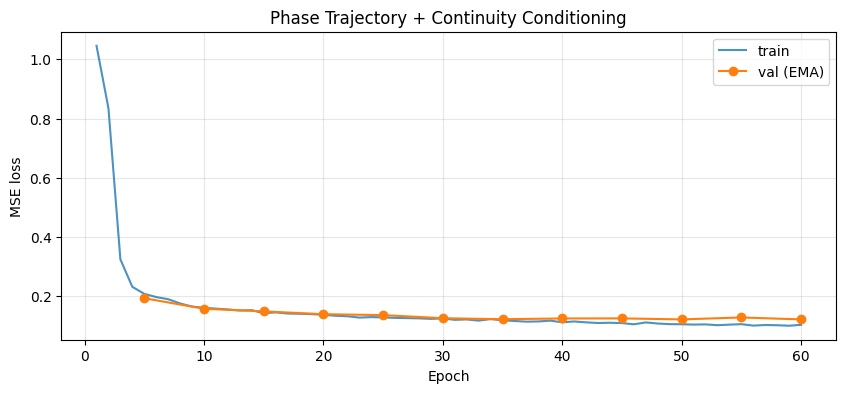

✓ /content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts/figures/phase_trajectory_continuity_loss.png


PosixPath('/content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts/figures/phase_trajectory_continuity_loss.png')

In [9]:
plot_loss_curve(
    train_losses,
    val_log,
    FIGURES_DIR / cfg.artifacts.loss_plot_name,
    title=cfg.display_name,
)


## 8. Offline Phase-Continuity Sensitivity

=== Output difference from 'in-dist (q50)' baseline ===
  OOD-low (q25-1.5IQR) (Δf=-0.500 Hz): RMSE = 0.3395
   in-dist (q25) (Δf=-0.125 Hz): RMSE = 0.1129
   in-dist (q50) (Δf=+0.000 Hz): RMSE = 0.0000
   in-dist (q75) (Δf=+0.125 Hz): RMSE = 0.1120
  OOD-high (q75+1.5IQR) (Δf=+0.500 Hz): RMSE = 0.3640


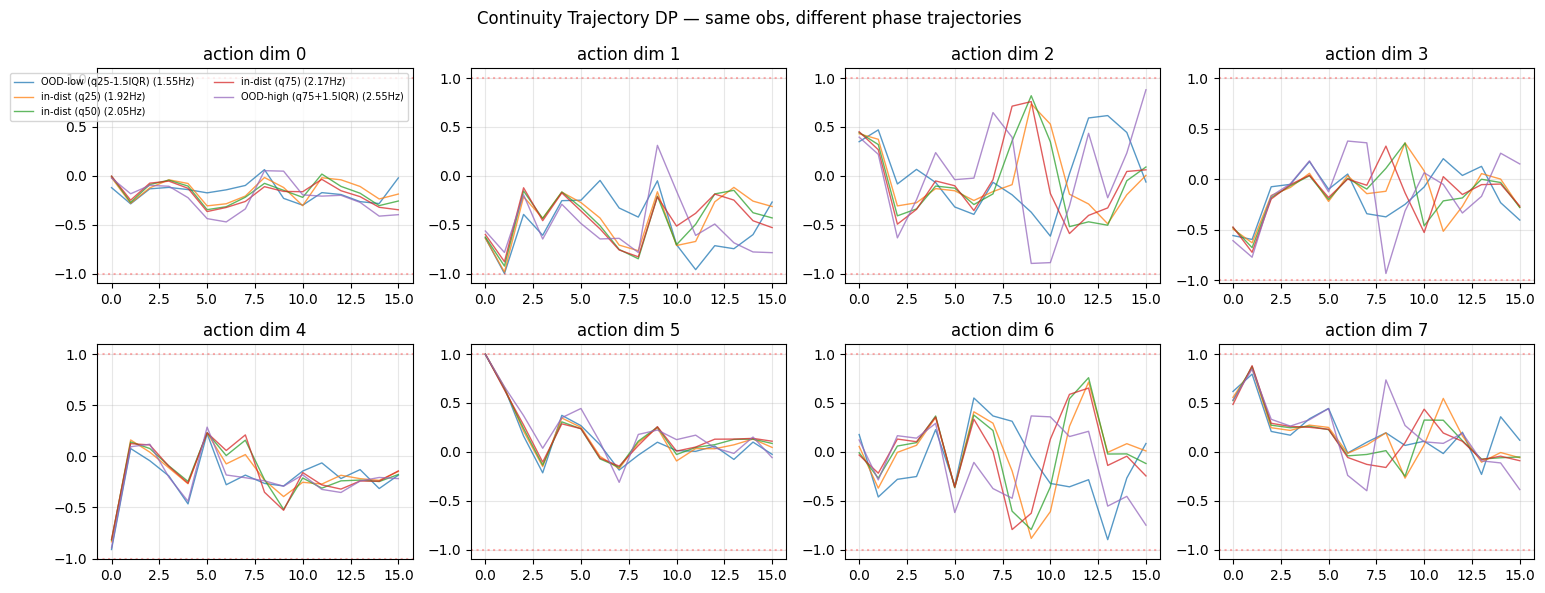

✓ /content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts/figures/phase_trajectory_continuity_sensitivity.png


PosixPath('/content/drive/MyDrive/phase_conditioned_diffusion_policy (1)/artifacts/figures/phase_trajectory_continuity_sensitivity.png')

In [10]:
freq_protocol = build_frequency_sweep_protocol(data, n_in_dist=3, ood_iqr_scale=1.5)
freqs = freq_protocol.sweep_freqs.tolist()
labels = freq_protocol.zone_labels.tolist()

ep_obs = val_ds[0]['obs'].unsqueeze(0)
samples_by_freq = sample_frequency_variants(
    model,
    ema,
    ns_config,
    ep_obs,
    data,
    trajectory_phase_continuity_sample_cond_fn,
    freqs,
    labels,
    device=device,
    num_inference_steps=NUM_INFERENCE_STEPS,
    dt=cfg.evaluation.dt,
    seed=data['seed'],
    reference_label=labels[2],
)

plot_action_chunks(
    samples_by_freq,
    FIGURES_DIR / 'phase_trajectory_continuity_sensitivity.png',
    title='Continuity Trajectory DP — same obs, different phase trajectories',
    act_dim=data['ACT_DIM'],
)
